# Vroegsignalering — Effectiveness Analysis

## Purpose
Early-warning systems for problematic debt are designed to reach households before their situation
escalates. But reaching someone is only the first step — the real question is whether that contact actually
**helps people get back on track**. This notebook looks beyond *"did we make contact?"* to ask
*"did it work?"*, by measuring whether households stay out of trouble after a case is closed.

## What we measure
We define success as a household **not returning with a new signal** in the months after its case is closed.
Around that single idea, the notebook builds up from a broad picture to a focused analysis:

- **The bigger picture** — how many signals come in, who reports them, and how cases are handled and resolved.
- **What actually works** — how the way a household is contacted (the method, the timing, their response)
  relates to whether they return, using statistical models with honest caveats about what the data can and
  cannot prove.

**Privacy first** - Although this notebook works with anonymised data, it never prints or exports individual records; every result is an aggregate statistic or chart.

## The data
Each export shares the same three core tabs — **Signalen** (signals), **Meldingen** (reports/cases) and
**Melders** (reporters) — alongside contact tabs that vary by municipality. The pieces fit together through
shared reference numbers, letting us follow a household's journey from first signal to final outcome.


## 0. Install Dependencies

Run this cell once to install all required Python libraries.
If the packages are already present in your environment this step will be skipped automatically.


In [1]:
%pip install pandas numpy matplotlib seaborn openpyxl statsmodels scipy --quiet


Note: you may need to restart the kernel to use updated packages.


## 1. Setup

Import all required libraries and configure chart styling.
**Update the `FILE` variable** on the second line of the cell below if the export file has a different name or location.


In [2]:
# Force a NON-blocking, headless plotting backend. Without this, plt.show() can
# block forever waiting for a GUI window (TkAgg/QtAgg/MacOSX) — which makes the
# first plotting cell appear to "hang". 'inline' renders in the notebook and is
# non-blocking; if IPython is unavailable we fall back to the headless 'Agg'.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    import matplotlib
    matplotlib.use('Agg')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Configuration ─────────────────────────────────────────────────────────────
FILE     = Path('bi_export_sample.xlsx')   # ← update to real file path if needed
DATE_FMT = '%d-%m-%Y'

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')
COLORS = sns.color_palette('Set2')

# ══════════════════════════════════════════════════════════════════════════════
#  RESULTS-FILE CAPTURE
#  Every print(), every table shown with display(), and every chart shown with
#  plt.show() is automatically recorded AND written to a single self-contained
#  HTML file (elsa_results_report.html) at the end (Section 15).
#  Send that one file back — it opens in any browser and embeds all charts.
#  Cell outputs still appear in the notebook as normal.
# ══════════════════════════════════════════════════════════════════════════════
import io as _io, base64 as _b64, html as _html, datetime as _dt, builtins as _bi
from IPython.display import display as _ipy_display   # the REAL display (safe to re-import)

REPORT_PATH   = (FILE.parent if hasattr(FILE, 'parent') else Path('.')) / 'elsa_results_report.html'
_REPORT_BLOCKS = []

def _report_add(html_str):
    _REPORT_BLOCKS.append(html_str)

def _report_section(title):
    _report_add(f"<h2 class='sec'>{_html.escape(str(title))}</h2>")

# Tee print() → real stdout + report. builtins.print is always the genuine print,
# so re-running this cell never stacks wrappers on top of each other.
_orig_print = _bi.print
def print(*args, **kwargs):
    _orig_print(*args, **kwargs)
    sep = kwargs.get('sep', ' '); end = kwargs.get('end', '\n')
    _report_add(f"<pre>{_html.escape(sep.join(str(a) for a in args) + end)}</pre>")

# Tee display() → real display + report. _ipy_display is imported straight from
# IPython above, NOT taken from the namespace, so it can never become this wrapper
# (which previously caused infinite recursion when the cell was run twice).
def display(obj, *args, **kwargs):
    _ipy_display(obj, *args, **kwargs)
    try:
        if isinstance(obj, pd.DataFrame):
            _report_add(obj.to_html(border=0))
        elif isinstance(obj, pd.Series):
            _report_add(obj.to_frame().to_html(border=0))
        else:
            _report_add(f"<pre>{_html.escape(str(obj))}</pre>")
    except Exception:
        pass

# Tee plt.show() → embed the current figure as a PNG. Guarded so that re-running
# this cell does not wrap an already-wrapped show() (which would double-capture).
if not getattr(plt.show, '_elsa_wrapped', False):
    _orig_show = plt.show
    def _report_show(*args, **kwargs):
        fig = plt.gcf()
        try:
            buf = _io.BytesIO()
            fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
            buf.seek(0)
            _report_add(f"<img src='data:image/png;base64,{_b64.b64encode(buf.read()).decode()}'/>")
        except Exception:
            pass
        _orig_show(*args, **kwargs)
    _report_show._elsa_wrapped = True
    plt.show = _report_show


### 1a. Load Data

Read all tabs from the Excel file, parse date columns to a consistent format, and define a helper function that converts Dutch `Ja`/`Nee` text values to booleans.
Row counts are printed at the end to confirm the file loaded correctly — no actual data values are shown.


In [3]:
_report_section('1a. Load Data')
xls = pd.ExcelFile(FILE)

signalen  = pd.read_excel(xls, 'Signalen')
meldingen = pd.read_excel(xls, 'Meldingen')
melders   = pd.read_excel(xls, 'Melders')

FIXED_TABS = {'Signalen', 'Meldingen', 'Melders'}
extra_tabs = {name: pd.read_excel(xls, name)
              for name in xls.sheet_names if name not in FIXED_TABS}

# ── Parse date columns (robust to already-datetime cells and other formats) ───
RAW_DATE_SAMPLES = {}   # original text of date columns, captured BEFORE parsing (for v2)
def parse_dates(df, cols):
    for c in cols:
        if c not in df.columns:
            continue
        s = df[c]
        if pd.api.types.is_datetime64_any_dtype(s):
            continue                      # Excel already gave real date cells
        ex = s.dropna().astype(str).head(3).tolist()   # example raw values reveal the format
        if ex:
            RAW_DATE_SAMPLES.setdefault(c, ex)
        parsed = pd.to_datetime(s, format=DATE_FMT, errors='coerce')
        if parsed.notna().mean() < 0.5:   # fixed format matched almost nothing
            parsed = pd.to_datetime(s, dayfirst=True, errors='coerce')
        df[c] = parsed

parse_dates(signalen,  ['Datum melding', 'Datum doorgezet', 'Startdatum contact'])
parse_dates(meldingen, ['Afgerond d.d.', 'Gezien d.d.'])
for df in extra_tabs.values():
    date_cols = [c for c in df.columns if 'datum' in c.lower() or c.lower() == 'datum']
    parse_dates(df, date_cols)

# ── Ja/Nee → boolean helper ───────────────────────────────────────────────────
def ja_nee(series):
    return series.astype(str).str.strip().str.lower().map({'ja': True, 'nee': False})

# ── Confirm tabs loaded (row counts only — no raw data) ───────────────────────
all_tabs = [('Signalen', signalen), ('Meldingen', meldingen), ('Melders', melders),
            *extra_tabs.items()]
for name, df in all_tabs:
    print(f"  {name:<35} {len(df):>7,} rows")


  Signalen                                  1 rows
  Meldingen                                 1 rows
  Melders                                   1 rows
  Tussenresultaat                           1 rows
  Eindresultaat                             1 rows
  Follow-Up resultaat                       1 rows


## 2. Dataset Profile — Knowledge Base for the Next Version

The real export is seen **only once** when this notebook runs, and only this report comes back.
So this section banks a thorough, privacy-safe **profile of the dataset** — schema, exact category labels,
value ranges, date coverage and join integrity — so the next version of the analysis can be written
**without needing to see the raw data again**.

Everything here is aggregate metadata: counts, percentages, ranges and (for low-cardinality, non-identifier
columns) the list of distinct category labels. **No individual records are shown.** A machine-readable JSON
copy of the whole profile is printed at the end of the section (2e) so it can be copied out and reused.


### 2a. Schema — tabs, columns, dtypes, missingness, cardinality

In [4]:
_report_section('2a. Schema — tabs, columns, dtypes, missingness, cardinality')
# Columns that must never have their raw values shown (identifiers / personal / free text)
SENSITIVE_COLS = {
    'Hash', 'SignaalID', 'Meldingnummer', 'ID', 'Melder ID', 'Postcode',
    'Naam medewerker', 'Melder', 'Melder (submerk)', 'Onderwerp',
    'Toelichting bij de FollowUp', 'Verwijzing anders namelijk', 'Waarnaar is verwezen',
}
CATEGORICAL_MAX = 50   # only list distinct values for columns with at most this many

def schema_table(df):
    return pd.DataFrame({
        'dtype':    df.dtypes.astype(str),
        'non_null': df.count(),
        'null_%':   (df.isnull().sum() / max(len(df), 1) * 100).round(1),
        'n_unique': df.nunique(dropna=True),
    })

for name, df in all_tabs:
    print(f"\n══ {name}: {len(df):,} rows × {df.shape[1]} cols ══")
    display(schema_table(df))



══ Signalen: 1 rows × 28 cols ══


,dtype,non_null,null_%,n_unique
SignaalID,int64,1,0.0,1
Hash,str,1,0.0,1
Gemeente,float64,0,100.0,0
Datum melding,datetime64[us],1,0.0,1
Melder (submerk),float64,0,100.0,0
Postcode,str,1,0.0,1
Wijk,str,1,0.0,1
Bakje,float64,0,100.0,0
Recidive,str,1,0.0,1
Schuiver,str,1,0.0,1



══ Meldingen: 1 rows × 11 cols ══


,dtype,non_null,null_%,n_unique
Meldingnummer,int64,1,0.0,1
Gemeente,str,1,0.0,1
Aantal melders,int64,1,0.0,1
Ingetrokken,str,1,0.0,1
Onterecht,str,1,0.0,1
Afgerond,str,1,0.0,1
Afgerond d.d.,datetime64[us],1,0.0,1
Bereikt,str,1,0.0,1
Uitvoerder,str,1,0.0,1
Gezien,str,1,0.0,1



══ Melders: 1 rows × 3 cols ══


...

,dtype,non_null,null_%,n_unique
ID,int64,1,0.0,1
Meldingnummer,int64,1,0.0,1
Datum contactpoging,datetime64[us],1,0.0,1
Naam medewerker,str,1,0.0,1
Wijze van contactpoging,str,1,0.0,1
Dagdeel,str,1,0.0,1
Persoon bereikt,str,1,0.0,1
Wil de klant hulp,float64,0,100.0,0
Wilt u de situatie invullen,float64,0,100.0,0
Inkomensbronnen,float64,0,100.0,0



══ Eindresultaat: 1 rows × 20 cols ══


,dtype,non_null,null_%,n_unique
ID,int64,1,0.0,1
Meldingnummer,int64,1,0.0,1
Datum contactpoging,datetime64[us],1,0.0,1
Naam medewerker,str,1,0.0,1
Wijze van contactpoging,str,1,0.0,1
Dagdeel,str,1,0.0,1
Persoon bereikt,str,1,0.0,1
Wil de klant hulp,str,1,0.0,1
Wilt u de situatie invullen,str,1,0.0,1
Inkomensbronnen,float64,0,100.0,0



══ Follow-Up resultaat: 1 rows × 9 cols ══


,dtype,non_null,null_%,n_unique
ID,int64,1,0.0,1
Meldingnummer,int64,1,0.0,1
Datum,datetime64[us],1,0.0,1
Wijze van contact,str,1,0.0,1
Onderwerp,float64,0,100.0,0
Wilt u een nieuwe FollowUp inplannen,str,1,0.0,1
Op welke datum,datetime64[s],0,100.0,0
Bij wie,float64,0,100.0,0
Toelichting bij de FollowUp,float64,0,100.0,0


### 2b. Exact Category Labels & Frequencies

For every **low-cardinality, non-identifier** column, the full set of distinct values and their counts.
This is the most valuable part for writing correct mappings/normalisers next time — it pins down the exact
spelling and casing of every contact method, outcome, Ja/Nee token, etc.


In [5]:
_report_section('2b. Exact Category Labels & Frequencies')
for name, df in all_tabs:
    shown_any = False
    for col in df.columns:
        if col in SENSITIVE_COLS:
            continue
        nu = df[col].nunique(dropna=True)
        if nu < 1 or nu > 1000:
            continue
        if not shown_any:
            print(f"\n══ {name} ══")
            shown_any = True
        if nu <= CATEGORICAL_MAX:
            vc = df[col].value_counts(dropna=False)
            vc.index = vc.index.map(lambda x: '(blank)' if pd.isna(x) else str(x))
            print(f"\n• {col}  ({nu} distinct):")
            print(vc.to_string())
        else:
            # 50 < distinct <= 1000: list only the most common values
            vc = df[col].value_counts().head(15)
            print(f"\n• {col}  ({nu} distinct — showing top 15):")
            print(vc.to_string())



══ Signalen ══

• Datum melding  (1 distinct):
Datum melding
2021-03-25 00:00:00    1

• Wijk  (1 distinct):
Wijk
Centrum    1

• Recidive  (1 distinct):
Recidive
Nee    1

• Schuiver  (1 distinct):
Schuiver
Nee    1

• Match  (1 distinct):
Match
Ja    1

• Recidive maand-1  (1 distinct):
Recidive maand-1
Nee    1

• Recidive maand-2  (1 distinct):
Recidive maand-2
Nee    1

• Recidive maand-3  (1 distinct):
Recidive maand-3
Nee    1

• Recidive maand-4  (1 distinct):
Recidive maand-4
Nee    1

• Recidive maand-5  (1 distinct):
Recidive maand-5
Nee    1

• Recidive maand-6  (1 distinct):
Recidive maand-6
Nee    1

• Type melding  (1 distinct):
Type melding
Eropaf/Crisis    1

• Doorgezet  (1 distinct):
Doorgezet
Nee    1

• Minderjarige kinderen  (1 distinct):
Minderjarige kinderen
Nee    1

• Termijnbedrag  (1 distinct):
Termijnbedrag
0.0    1

• Achterstandsbedrag  (1 distinct):
Achterstandsbedrag
1.01    1

• Startdatum contact  (1 distinct):
Startdatum contact
2021-02-24 00:00:00 

### 2c. Numeric Ranges & Date Coverage

Ranges for numeric columns (to design bands from reality) and coverage / parse-success for date columns.


In [6]:
_report_section('2c. Numeric Ranges & Date Coverage')
for name, df in all_tabs:
    num = df.select_dtypes(include='number')
    num = num[[c for c in num.columns if c not in SENSITIVE_COLS]]
    if num.shape[1]:
        print(f"\n══ {name} — numeric columns ══")
        display(num.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2))

print("\n══ Date columns — coverage & parse success ══")
date_cols = {'Signalen': ['Datum melding', 'Datum doorgezet', 'Startdatum contact'],
             'Meldingen': ['Afgerond d.d.', 'Gezien d.d.']}
tab_lookup = dict(all_tabs)
for tab, cols in date_cols.items():
    if tab not in tab_lookup:
        continue
    df = tab_lookup[tab]
    for c in cols:
        if c in df.columns and pd.api.types.is_datetime64_any_dtype(df[c]):
            s = df[c]
            ok = s.notna().mean() * 100
            print(f"  {tab}.{c:<20} parsed={ok:5.1f}%  "
                  f"range={s.min().date() if s.notna().any() else 'n/a'} → "
                  f"{s.max().date() if s.notna().any() else 'n/a'}")

print("\n══ Raw date formats (original text, before parsing) ══")
if RAW_DATE_SAMPLES:
    for _col, _ex in RAW_DATE_SAMPLES.items():
        print(f"  {_col:<22} e.g. {_ex}")
else:
    print("  All date columns were already proper date cells (no text parsing needed).")


══ Signalen — numeric columns ══


,count,mean,std,min,25%,50%,75%,max
Gemeente,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bakje,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soort melding,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Leeftijd,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Termijnbedrag,1.0,0.00,NaN,0.00,0.00,0.00,0.00,0.00
Achterstandsbedrag,1.0,1.01,NaN,1.01,1.01,1.01,1.01,1.01



══ Meldingen — numeric columns ══


,count,mean,std,min,25%,50%,75%,max
Aantal melders,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0



══ Tussenresultaat — numeric columns ══


...


══ Eindresultaat — numeric columns ══


,count,mean,std,min,25%,50%,75%,max
Inkomensbronnen,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zijn of worden er inkomensverruimende voorzieningen toegepast,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zijn er nog meer schuldeisers,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wat is globaal het totale schuldbedrag,1.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
Belangrijkste oorzaak schulden,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zijn er minderjarige kinderen,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wat is de voortgang,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soort verwijzing,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



══ Follow-Up resultaat — numeric columns ══


,count,mean,std,min,25%,50%,75%,max
Bij wie,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



══ Date columns — coverage & parse success ══
  Signalen.Datum melding        parsed=100.0%  range=2021-03-25 → 2021-03-25
  Signalen.Datum doorgezet      parsed=  0.0%  range=n/a → n/a
  Signalen.Startdatum contact   parsed=100.0%  range=2021-02-24 → 2021-02-24
  Meldingen.Afgerond d.d.        parsed=100.0%  range=2021-04-26 → 2021-04-26
  Meldingen.Gezien d.d.          parsed=100.0%  range=2021-04-20 → 2021-04-20

══ Raw date formats (original text, before parsing) ══
  Datum melding          e.g. ['25-03-2021']
  Startdatum contact     e.g. ['24-02-2021']
  Afgerond d.d.          e.g. ['26-04-2021']
  Gezien d.d.            e.g. ['20-04-2021']
  Datum contactpoging    e.g. ['23-03-2021']
  Datum                  e.g. ['19-04-2021']


### 2d. Join Integrity & Structural Distributions

How the tabs link to each other (orphan/duplicate rates) and the structural distributions that determine
what is analysable next time: signals per household, contact attempts per case, follow-up availability,
and cases per municipality.


In [7]:
_report_section('2d. Join Integrity & Structural Distributions')
print("── Join integrity ──")
sig_with_mld = signalen['Meldingnummer'].notna().mean() * 100
print(f"  Signalen with a Meldingnummer (linkable to Meldingen): {sig_with_mld:.1f}%")

mld_keys = set(meldingen['Meldingnummer'].dropna())
for tab in ['Tussenresultaat', 'Eindresultaat', 'Follow-Up resultaat']:
    if tab in extra_tabs and 'Meldingnummer' in extra_tabs[tab].columns:
        ids = extra_tabs[tab]['Meldingnummer'].dropna()
        match = ids.isin(mld_keys).mean() * 100 if len(ids) else 0
        print(f"  {tab}: {len(ids):,} rows, {match:.1f}% match a Meldingen case")

if 'Melder ID' in signalen.columns:
    melder_ids = set(melders['ID'].dropna())
    m = signalen['Melder ID'].dropna()
    print(f"  Signalen.Melder ID matching Melders registry: "
          f"{m.isin(melder_ids).mean()*100:.1f}%")

dup_mld = int(meldingen['Meldingnummer'].duplicated().sum())
print(f"  Duplicate Meldingnummer in Meldingen: {dup_mld:,}")

print("\n── Recidive structure (signals per household Hash) ──")
sph = signalen.dropna(subset=['Hash']).groupby('Hash').size()
if len(sph):
    print(f"  Households (unique Hash): {len(sph):,}")
    print(f"  Signals per household: mean={sph.mean():.2f}  median={sph.median():.0f}  max={sph.max()}")
    multi = (sph > 1).mean() * 100
    print(f"  Households with >1 signal (recidive present): {multi:.1f}%")

print("\n── Contact attempts per case ──")
att = []
for tab in ['Tussenresultaat', 'Eindresultaat']:
    if tab in extra_tabs:
        att.append(extra_tabs[tab][['Meldingnummer']])
if att:
    apc = pd.concat(att).dropna().groupby('Meldingnummer').size()
    print(f"  Cases with ≥1 attempt: {len(apc):,}")
    print(f"  Attempts per case: mean={apc.mean():.2f}  median={apc.median():.0f}  max={apc.max()}")

print("\n── Follow-up availability for recidive windows ──")
if 'Afgerond d.d.' in meldingen.columns and pd.api.types.is_datetime64_any_dtype(meldingen['Afgerond d.d.']):
    dmax = signalen['Datum melding'].max()
    closed_ct = ja_nee(meldingen['Afgerond'])
    for label, days in {'6 months': 182, '9 months': 273}.items():
        ok = (closed_ct.fillna(False) &
              meldingen['Afgerond d.d.'].notna() &
              ((meldingen['Afgerond d.d.'] + pd.Timedelta(days=days)) <= dmax)).sum()
        print(f"  Closed cases with ≥{label} follow-up: {ok:,}")

print("\n── Cases per municipality (multilevel feasibility) ──")
if 'Gemeente' in meldingen.columns:
    cpm = meldingen['Gemeente'].value_counts()
    print(f"  Municipalities: {cpm.size}  |  cases/municipality "
          f"mean={cpm.mean():.0f} median={cpm.median():.0f} min={cpm.min()} max={cpm.max()}")

print("\n── One household per case? (Meldingnummer -> Hash) ──")
_sl  = signalen.dropna(subset=['Meldingnummer', 'Hash'])
_hpc = _sl.groupby('Meldingnummer')['Hash'].nunique()
_multi = int((_hpc > 1).sum())
print(f"  Cases with linked signals: {len(_hpc):,}")
print(f"  ...mapping to >1 distinct household Hash: {_multi:,} "
      f"({_multi / max(len(_hpc), 1) * 100:.2f}%)")
print("  OK - one household per case; case-level recidive logic holds." if _multi == 0
      else "  WARNING - some cases span multiple households; revisit the one-Hash-per-case assumption.")

print("\n── Signalen -> Meldingen referential integrity ──")
_sig_mld = signalen['Meldingnummer'].dropna()
_orphan  = int((~_sig_mld.isin(mld_keys)).sum())
print(f"  Signals carrying a Meldingnummer: {len(_sig_mld):,}")
print(f"  ...whose Meldingnummer is NOT found in Meldingen (orphans): {_orphan:,} "
      f"({_orphan / max(len(_sig_mld), 1) * 100:.2f}%)")

── Join integrity ──
  Signalen with a Meldingnummer (linkable to Meldingen): 0.0%
  Tussenresultaat: 1 rows, 100.0% match a Meldingen case
  Eindresultaat: 1 rows, 100.0% match a Meldingen case
  Follow-Up resultaat: 1 rows, 100.0% match a Meldingen case
  Signalen.Melder ID matching Melders registry: 100.0%
  Duplicate Meldingnummer in Meldingen: 0

── Recidive structure (signals per household Hash) ──
  Households (unique Hash): 1
  Signals per household: mean=1.00  median=1  max=1
  Households with >1 signal (recidive present): 0.0%

── Contact attempts per case ──
  Cases with ≥1 attempt: 1
  Attempts per case: mean=2.00  median=2  max=2

── Follow-up availability for recidive windows ──
  Closed cases with ≥6 months follow-up: 0
  Closed cases with ≥9 months follow-up: 0

── Cases per municipality (multilevel feasibility) ──
  Municipalities: 1  |  cases/municipality mean=1 median=1 min=1 max=1

── One household per case? (Meldingnummer -> Hash) ──
  Cases with linked signals: 0


## 3. Signal Volume & Distribution

How many signals arrive per month, and which signal types are most common?


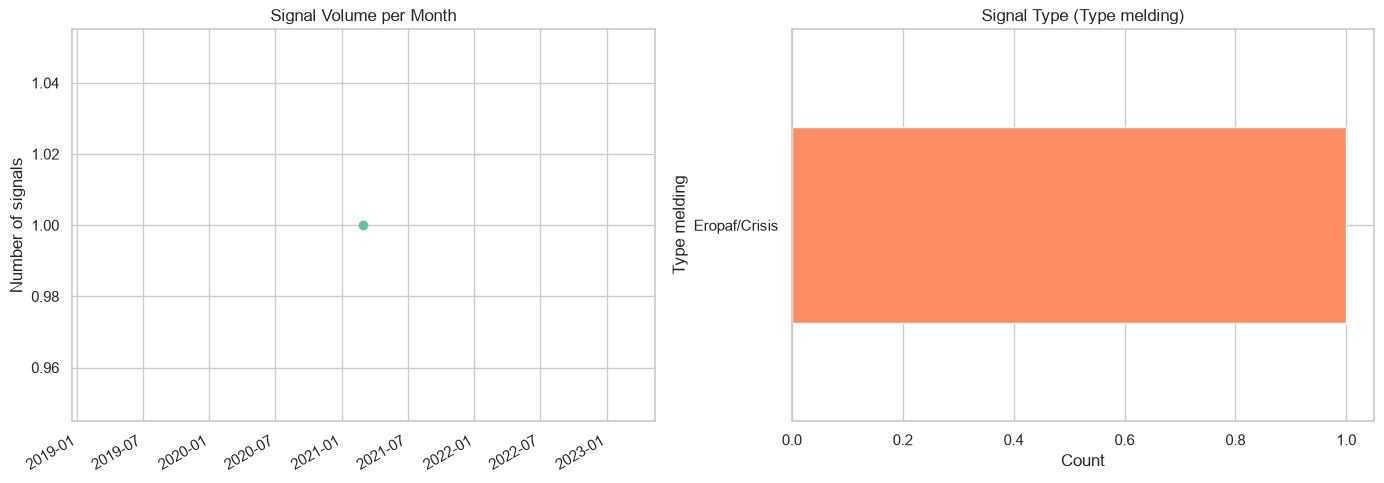

Total signals      : 1
Valid signal dates : 1 (100.0%)
Date range         : 2021-03-25 → 2021-03-25

Signal type counts:
Type melding
Eropaf/Crisis    1


In [8]:
_report_section('3. Signal Volume & Distribution')
# Use only valid dates; convert to monthly Timestamps for a clean, fast x-axis.
# (Garbage/NaT dates are dropped so a few bad rows can't blow up the plot range.)
_valid_dates = signalen['Datum melding'].dropna()
monthly = (_valid_dates.dt.to_period('M').dt.to_timestamp()
           .value_counts().sort_index().rename('signals'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(monthly) > 0:
    monthly.plot(ax=axes[0], marker='o', color=COLORS[0], linewidth=2)
axes[0].set_title('Signal Volume per Month')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of signals')

type_counts = signalen['Type melding'].value_counts()
type_counts.plot.barh(ax=axes[1], color=COLORS[1])
axes[1].set_title('Signal Type (Type melding)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f"Total signals      : {len(signalen):,}")
print(f"Valid signal dates : {len(_valid_dates):,} "
      f"({len(_valid_dates)/max(len(signalen),1)*100:.1f}%)")
if len(_valid_dates) > 0:
    print(f"Date range         : {_valid_dates.min().date()} → {_valid_dates.max().date()}")
else:
    print("Date range         : no parseable dates in 'Datum melding'")
print()
print("Signal type counts:")
print(type_counts.to_string())


### 3a. Reporter (Melder) Analysis

Which organisations are sending signals, and in what volume?

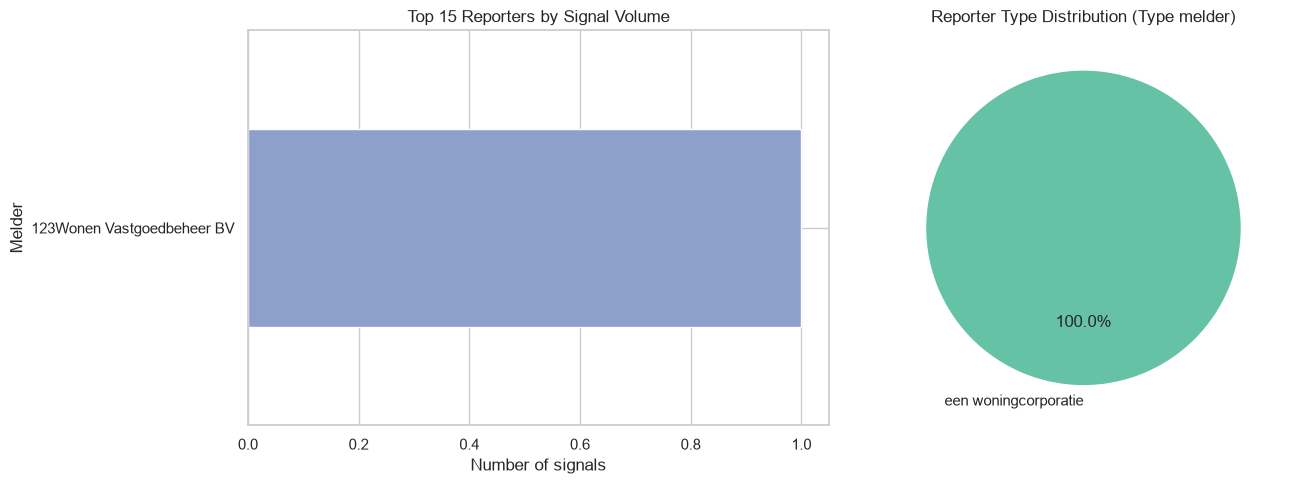

Reporter type — signal counts:
                      signals  pct_of_total
Type melder                                
een woningcorporatie        1         100.0


In [9]:
_report_section('3a. Reporter (Melder) Analysis')
sig_with_melder = signalen.merge(
    melders.rename(columns={'ID': 'Melder ID'}), on='Melder ID', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_reporters = sig_with_melder['Melder'].value_counts().head(15)
top_reporters.sort_values().plot.barh(ax=axes[0], color=COLORS[2])
axes[0].set_title('Top 15 Reporters by Signal Volume')
axes[0].set_xlabel('Number of signals')

type_melder = sig_with_melder['Type melder'].value_counts()
type_melder.plot.pie(ax=axes[1], autopct='%1.1f%%',
                     colors=sns.color_palette('Set2', len(type_melder)),
                     startangle=90)
axes[1].set_title('Reporter Type Distribution (Type melder)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Reporter type — signal counts:")
print(
    type_melder.rename('signals')
    .to_frame()
    .assign(pct_of_total=(type_melder / len(signalen) * 100).round(1))
    .to_string()
)


## 4. Signal → Report Conversion

A signal is "forwarded" (`Doorgezet = Ja`) when the municipality decides it warrants follow-up.
We measure the overall forwarding rate and whether it differs by signal type or reporter type.


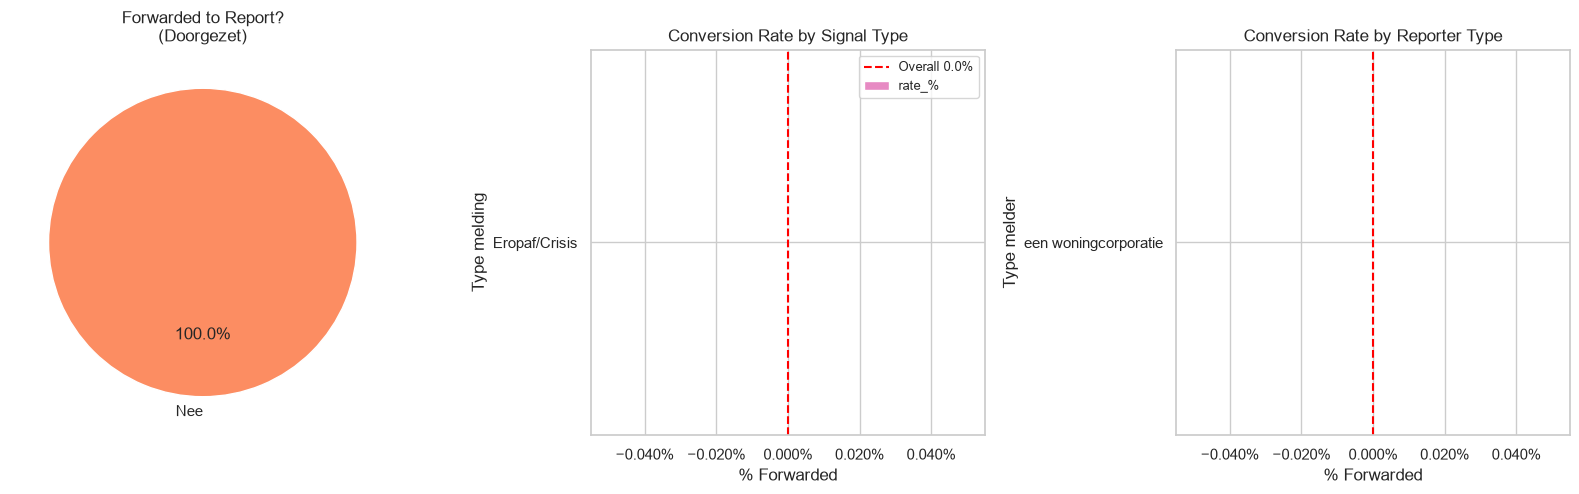

Overall forwarding rate: 0 / 1 = 0.0%

Conversion by signal type:
               forwarded  total  rate_%
Type melding                           
Eropaf/Crisis          0      1     0.0


In [10]:
_report_section('4. Signal → Report Conversion')
signalen['doorgezet_bool'] = ja_nee(signalen['Doorgezet'])
signalen['has_report']     = signalen['Meldingnummer'].notna()

total       = len(signalen)
n_forwarded = int(signalen['doorgezet_bool'].sum())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall pie
doorgezet_counts = signalen['Doorgezet'].value_counts(dropna=False)
doorgezet_counts.index = doorgezet_counts.index.fillna('(blank)')
doorgezet_counts.plot.pie(ax=axes[0], autopct='%1.1f%%',
                          colors=[COLORS[1], COLORS[0], COLORS[3]], startangle=90)
axes[0].set_title('Forwarded to Report?\n(Doorgezet)')
axes[0].set_ylabel('')

# By signal type
type_conv = (signalen.groupby('Type melding')['doorgezet_bool']
             .agg(forwarded='sum', total='count'))
type_conv['rate_%'] = type_conv['forwarded'] / type_conv['total'] * 100
type_conv['rate_%'].sort_values().plot.barh(ax=axes[1], color=COLORS[3])
axes[1].axvline(n_forwarded / total * 100, color='red', linestyle='--',
                linewidth=1.5, label=f'Overall {n_forwarded/total*100:.1f}%')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Conversion Rate by Signal Type')
axes[1].set_xlabel('% Forwarded')
axes[1].legend(fontsize=9)

# By reporter type
if 'Type melder' in sig_with_melder.columns:
    sig_with_melder['doorgezet_bool'] = ja_nee(sig_with_melder['Doorgezet'])
    type_melder_conv = (sig_with_melder.groupby('Type melder')['doorgezet_bool']
                        .agg(forwarded='sum', total='count'))
    type_melder_conv['rate_%'] = (type_melder_conv['forwarded']
                                  / type_melder_conv['total'] * 100)
    type_melder_conv['rate_%'].sort_values().plot.barh(ax=axes[2], color=COLORS[4])
    axes[2].axvline(n_forwarded / total * 100, color='red', linestyle='--', linewidth=1.5)
    axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
    axes[2].set_title('Conversion Rate by Reporter Type')
    axes[2].set_xlabel('% Forwarded')

plt.tight_layout()
plt.show()

print(f"Overall forwarding rate: {n_forwarded:,} / {total:,} = {n_forwarded/total*100:.1f}%")
print()
print("Conversion by signal type:")
print(type_conv.sort_values('rate_%', ascending=False)
      .assign(**{'rate_%': type_conv['rate_%'].round(1)})
      .to_string())


## 5. Contact Effectiveness

Once a report exists, the municipality tries to reach the client. We look at:
- Overall reach rate (`Bereikt` in Meldingen)
- Reach rate per contact method and time of day
- How many attempts are typically needed


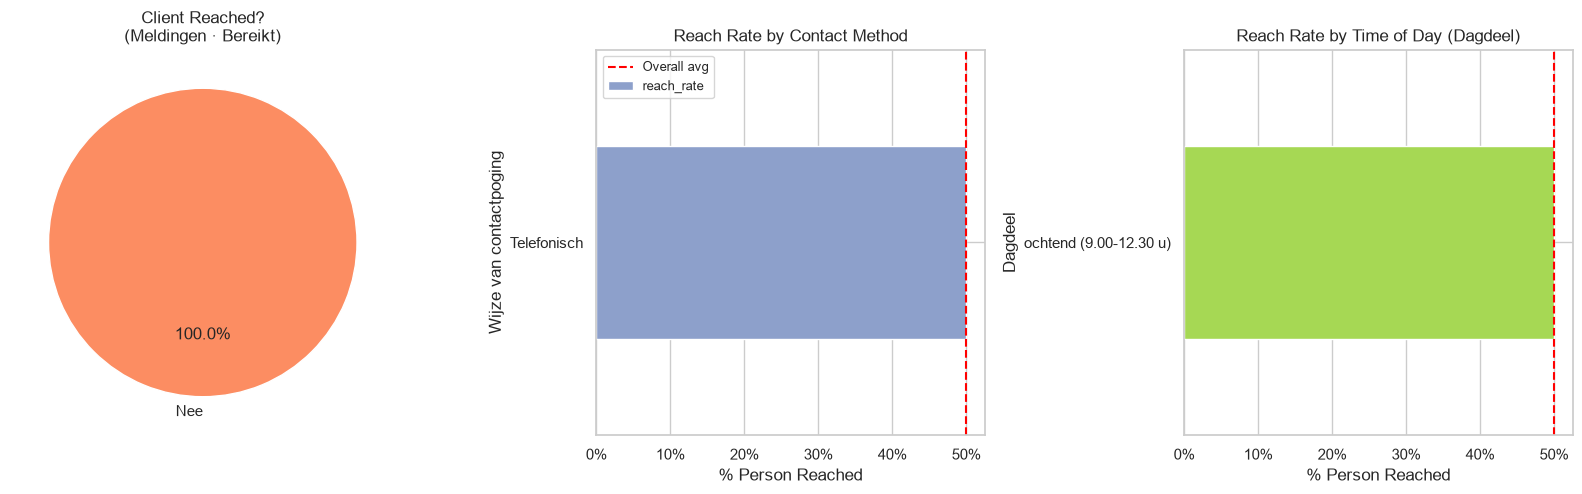

Reach rate (Meldingen · Bereikt): 0.0%
Total contact attempts logged  : 2

Reach rate by contact method:
                         reach_rate  n_attempts
Wijze van contactpoging                        
Telefonisch                    50.0           2


In [11]:
_report_section('5. Contact Effectiveness')
meldingen['bereikt_bool'] = ja_nee(meldingen['Bereikt'])
bereikt_rate = meldingen['bereikt_bool'].mean() * 100

contact_dfs = []
for tab_name in ['Tussenresultaat', 'Eindresultaat']:
    if tab_name in extra_tabs:
        df = extra_tabs[tab_name].copy()
        df['_tab'] = tab_name
        contact_dfs.append(df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bereikt_vc = meldingen['Bereikt'].value_counts(dropna=False)
bereikt_vc.index = bereikt_vc.index.fillna('(blank)')
bereikt_vc.plot.pie(ax=axes[0], autopct='%1.1f%%',
                    colors=[COLORS[1], COLORS[0]], startangle=90)
axes[0].set_title('Client Reached?\n(Meldingen · Bereikt)')
axes[0].set_ylabel('')

if contact_dfs:
    contacts = pd.concat(contact_dfs, ignore_index=True)
    contacts['bereikt_bool'] = ja_nee(contacts['Persoon bereikt'])

    method_reach = (contacts.groupby('Wijze van contactpoging')['bereikt_bool']
                    .agg(reach_rate='mean', n_attempts='count'))
    method_reach['reach_rate'] *= 100
    method_reach['reach_rate'].sort_values().plot.barh(ax=axes[1], color=COLORS[2])
    axes[1].axvline(contacts['bereikt_bool'].mean() * 100, color='red',
                    linestyle='--', linewidth=1.5, label='Overall avg')
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
    axes[1].set_title('Reach Rate by Contact Method')
    axes[1].set_xlabel('% Person Reached')
    axes[1].legend(fontsize=9)

    dagdeel_reach = (contacts.groupby('Dagdeel')['bereikt_bool']
                     .agg(reach_rate='mean', n_attempts='count'))
    dagdeel_reach['reach_rate'] *= 100
    dagdeel_reach['reach_rate'].sort_values().plot.barh(ax=axes[2], color=COLORS[4])
    axes[2].axvline(contacts['bereikt_bool'].mean() * 100, color='red',
                    linestyle='--', linewidth=1.5)
    axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
    axes[2].set_title('Reach Rate by Time of Day (Dagdeel)')
    axes[2].set_xlabel('% Person Reached')
else:
    for ax in axes[1:]:
        ax.text(0.5, 0.5, 'No contact-attempt tabs\nfound in this export',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.show()

print(f"Reach rate (Meldingen · Bereikt): {bereikt_rate:.1f}%")
if contact_dfs:
    print(f"Total contact attempts logged  : {len(contacts):,}")
    print()
    print("Reach rate by contact method:")
    print(method_reach.sort_values('reach_rate', ascending=False)
          .assign(reach_rate=method_reach['reach_rate'].round(1))
          .to_string())


## 6. Client Response & Outcomes

Once the client is reached, do they want help, and what is the final outcome?


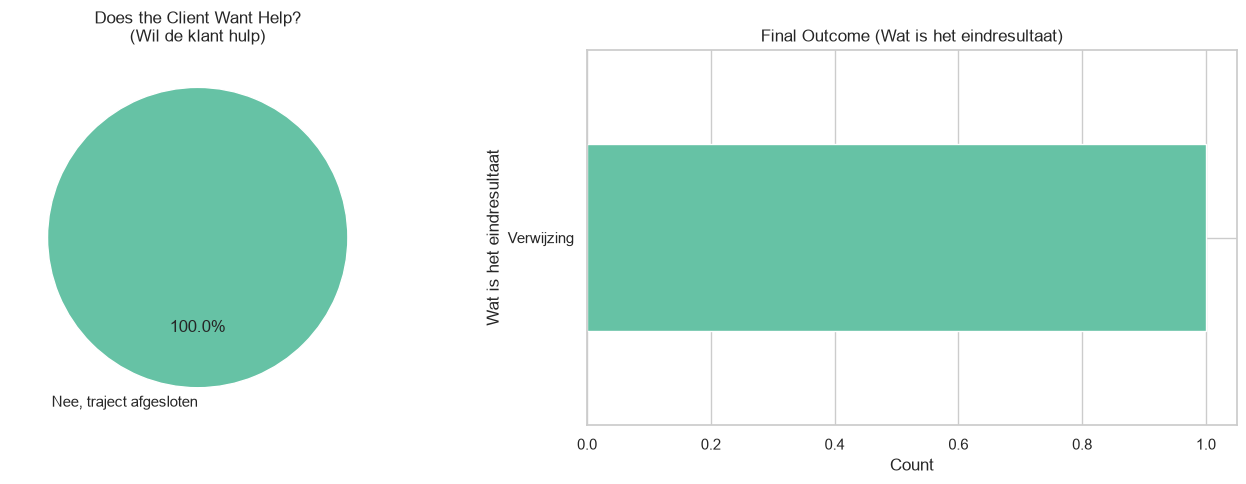

Outcome breakdown:
                          count   pct_
Wat is het eindresultaat              
Verwijzing                    1  100.0


In [12]:
_report_section('6. Client Response & Outcomes')
if 'Eindresultaat' in extra_tabs:
    eind = extra_tabs['Eindresultaat'].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    hulp_vc = eind['Wil de klant hulp'].value_counts(dropna=False)
    hulp_vc.index = hulp_vc.index.fillna('(not recorded)')
    hulp_vc.plot.pie(ax=axes[0], autopct='%1.1f%%',
                     colors=sns.color_palette('Set2', len(hulp_vc)), startangle=90)
    axes[0].set_title('Does the Client Want Help?\n(Wil de klant hulp)')
    axes[0].set_ylabel('')

    result_vc = eind['Wat is het eindresultaat'].value_counts(dropna=False)
    result_vc.index = result_vc.index.fillna('(not recorded)')
    result_vc.sort_values().plot.barh(ax=axes[1], color=COLORS[0])
    axes[1].set_title('Final Outcome (Wat is het eindresultaat)')
    axes[1].set_xlabel('Count')

    plt.tight_layout()
    plt.show()

    print("Outcome breakdown:")
    print(
        result_vc.rename('count')
        .to_frame()
        .assign(pct_=(result_vc / result_vc.sum() * 100).round(1))
        .sort_values('count', ascending=False)
        .to_string()
    )
else:
    print("No 'Eindresultaat' tab found in this export.")


## 7. Case Resolution & Timing

Case status breakdown and time from first signal to case closure.


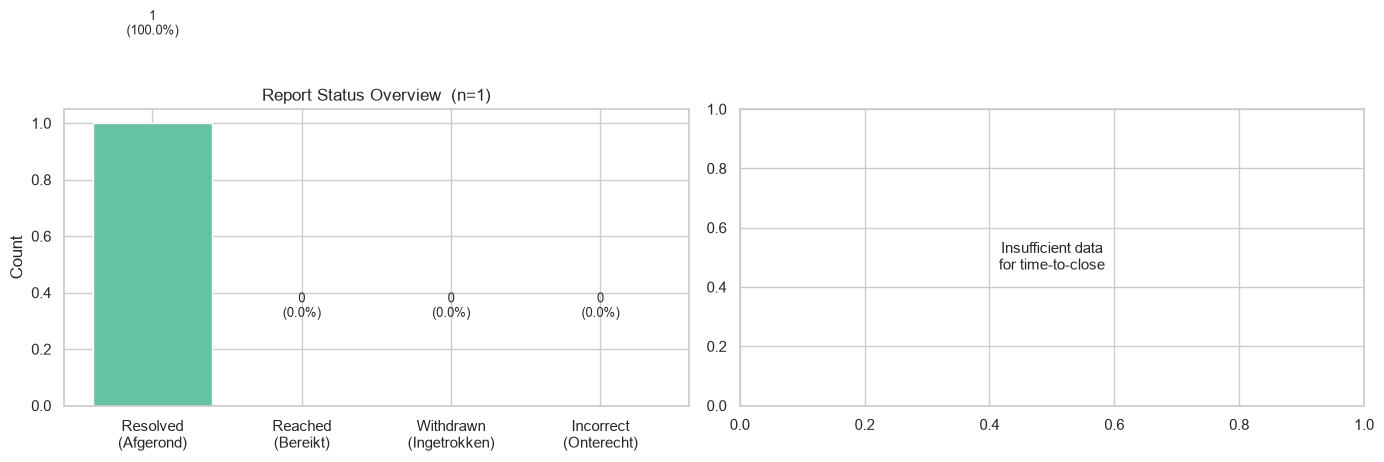

Status summary:
  Resolved (Afgerond)                 1  (100.0%)
  Reached (Bereikt)                   0  (0.0%)
  Withdrawn (Ingetrokken)             0  (0.0%)
  Incorrect (Onterecht)               0  (0.0%)


In [13]:
_report_section('7. Case Resolution & Timing')
meldingen['afgerond_bool']    = ja_nee(meldingen['Afgerond'])
meldingen['ingetrokken_bool'] = ja_nee(meldingen['Ingetrokken'])
meldingen['onterecht_bool']   = ja_nee(meldingen['Onterecht'])

earliest_signal = (signalen.dropna(subset=['Meldingnummer'])
                   .groupby('Meldingnummer')['Datum melding'].min()
                   .rename('Datum melding'))
mel = meldingen.join(earliest_signal, on='Meldingnummer')
mel['days_to_close'] = (mel['Afgerond d.d.'] - mel['Datum melding']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_mel = len(meldingen)
status = pd.Series({
    'Resolved\n(Afgerond)':     int(meldingen['afgerond_bool'].sum()),
    'Reached\n(Bereikt)':       int(meldingen['bereikt_bool'].sum()),
    'Withdrawn\n(Ingetrokken)': int(meldingen['ingetrokken_bool'].sum()),
    'Incorrect\n(Onterecht)':   int(meldingen['onterecht_bool'].sum()),
})
bars = axes[0].bar(status.index, status.values, color=COLORS[:4])
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                 f'{int(h):,}\n({h/n_mel*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title(f'Report Status Overview  (n={n_mel:,})')
axes[0].set_ylabel('Count')

dtc = mel['days_to_close'].dropna()
if len(dtc) > 1:
    dtc.hist(ax=axes[1], bins=min(30, len(dtc)), color=COLORS[2], edgecolor='white')
    axes[1].axvline(dtc.median(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Median: {dtc.median():.0f}d')
    axes[1].axvline(dtc.mean(), color='orange', linestyle=':', linewidth=1.5,
                    label=f'Mean: {dtc.mean():.0f}d')
    axes[1].set_title('Days from Signal to Case Closure')
    axes[1].set_xlabel('Days')
    axes[1].set_ylabel('Count')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Insufficient data\nfor time-to-close',
                ha='center', va='center', transform=axes[1].transAxes, fontsize=11)

plt.tight_layout()
plt.show()

print("Status summary:")
for label, count in status.items():
    print(f"  {label.replace(chr(10), ' '):<30} {count:>6,}  ({count/n_mel*100:.1f}%)")
if len(dtc) > 1:
    print(f"\nTime to close:  median={dtc.median():.0f}d  "
          f"mean={dtc.mean():.0f}d  p90={dtc.quantile(.9):.0f}d")


### 7a. Recidive — Repeated Signals

A recidive signal means the same household has sent a signal before.
This cell shows how the recidive rate evolves month by month and whether households with a recidive history are more or less likely to be forwarded to a report.


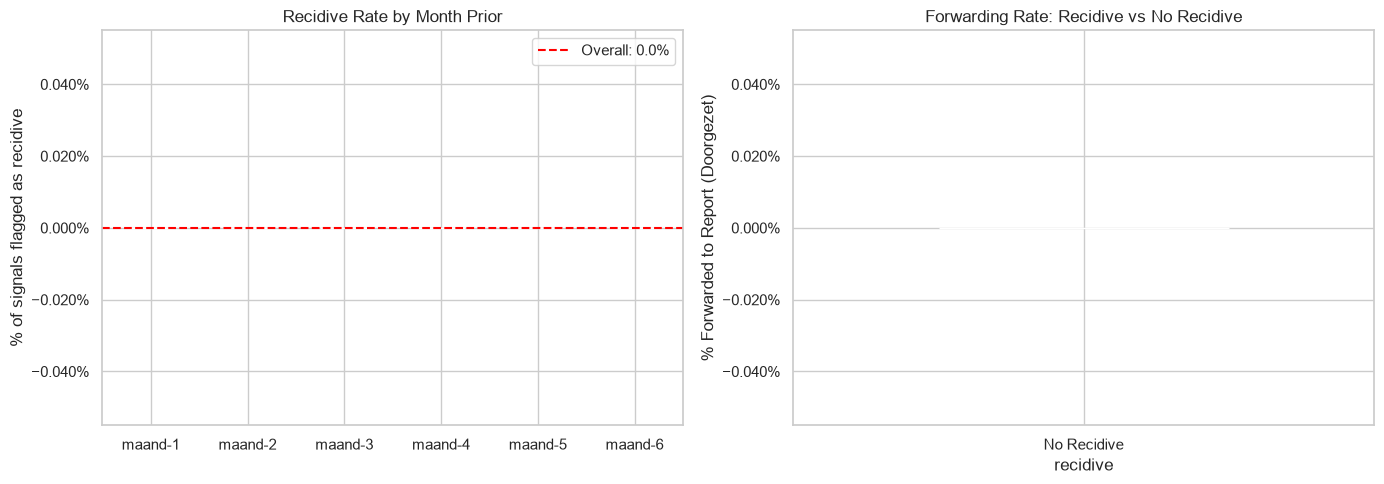

Overall recidive rate: 0.0%
maand-1    0.0
maand-2    0.0
maand-3    0.0
maand-4    0.0
maand-5    0.0
maand-6    0.0


In [14]:
_report_section('7a. Recidive — Repeated Signals')
recidive_cols = [c for c in signalen.columns if c.startswith('Recidive maand')]

if recidive_cols:
    rec_rates = {col.replace('Recidive ', ''): ja_nee(signalen[col]).mean() * 100
                 for col in recidive_cols}
    overall_rec = ja_nee(signalen['Recidive']).mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    pd.Series(rec_rates).plot.bar(ax=axes[0], color=COLORS[0])
    axes[0].axhline(overall_rec, color='red', linestyle='--', linewidth=1.5,
                    label=f'Overall: {overall_rec:.1f}%')
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[0].set_title('Recidive Rate by Month Prior')
    axes[0].set_ylabel('% of signals flagged as recidive')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend()

    rec_conv = (signalen
                .groupby(ja_nee(signalen['Recidive']).rename('recidive'))
                ['doorgezet_bool'].mean() * 100)
    rec_conv.index = rec_conv.index.map({True: 'Recidive', False: 'No Recidive'})
    rec_conv.plot.bar(ax=axes[1], color=[COLORS[1], COLORS[2]])
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[1].set_title('Forwarding Rate: Recidive vs No Recidive')
    axes[1].set_ylabel('% Forwarded to Report (Doorgezet)')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    print(f"Overall recidive rate: {overall_rec:.1f}%")
    print(pd.Series(rec_rates).round(1).rename('recidive_%').to_string())
else:
    print("No recidive month columns found.")


## 8. End-to-End Effectiveness Funnel

The full journey from signal receipt to resolved case.
Each stage shows the count and the percentage of all incoming signals that reach it.


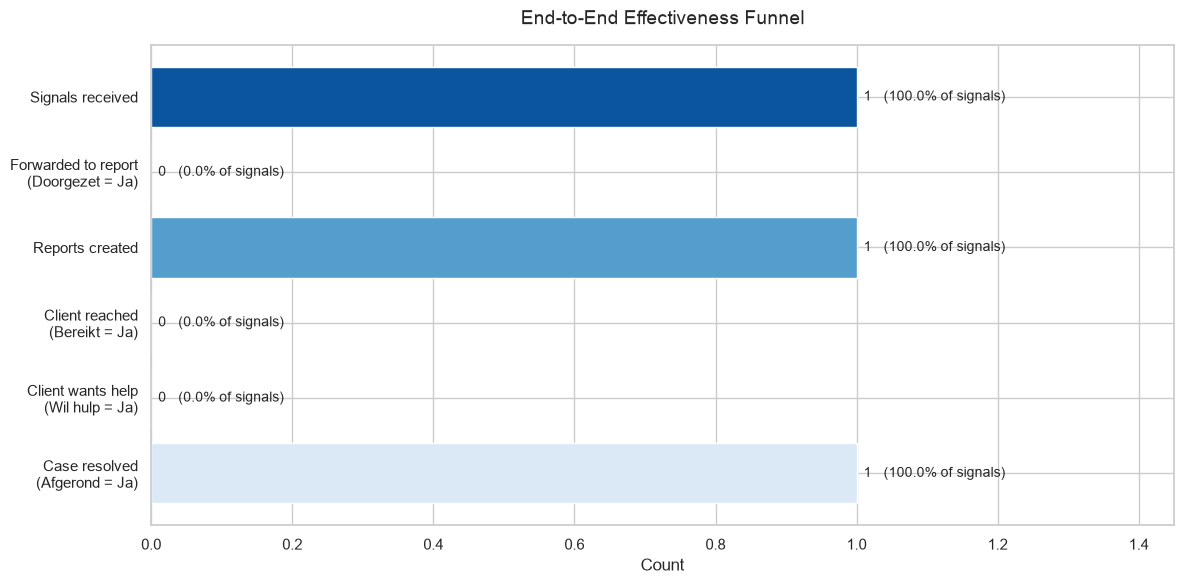


Funnel summary:
  Signals received                                      1  (100.0%)
  Forwarded to report (Doorgezet = Ja)                  0  (0.0%)
  Reports created                                       1  (100.0%)
  Client reached (Bereikt = Ja)                         0  (0.0%)
  Client wants help (Wil hulp = Ja)                     0  (0.0%)
  Case resolved (Afgerond = Ja)                         1  (100.0%)


In [15]:
_report_section('8. End-to-End Effectiveness Funnel')
n_signals   = len(signalen)
n_forwarded = int(ja_nee(signalen['Doorgezet']).sum())
n_reports   = len(meldingen)
n_reached   = int(meldingen['bereikt_bool'].sum())
n_resolved  = int(meldingen['afgerond_bool'].sum())

stages = ['Signals received',
          'Forwarded to report\n(Doorgezet = Ja)',
          'Reports created',
          'Client reached\n(Bereikt = Ja)']
values = [n_signals, n_forwarded, n_reports, n_reached]

if 'Eindresultaat' in extra_tabs:
    eind = extra_tabs['Eindresultaat']
    hulp_ja = (eind['Wil de klant hulp'].fillna('')
               .str.lower().str.startswith('ja').sum())
    stages.append('Client wants help\n(Wil hulp = Ja)')
    values.append(int(hulp_ja))

stages.append('Case resolved\n(Afgerond = Ja)')
values.append(n_resolved)

palette = sns.color_palette('Blues_r', len(stages))
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(stages)), values, color=palette)
for bar, val in zip(bars, values):
    pct = val / n_signals * 100
    ax.text(bar.get_width() + n_signals * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}   ({pct:.1f}% of signals)',
            va='center', fontsize=10)
ax.set_yticks(range(len(stages)))
ax.set_yticklabels(stages, fontsize=11)
ax.set_xlabel('Count')
ax.set_title('End-to-End Effectiveness Funnel', fontsize=14, pad=15)
ax.set_xlim(0, n_signals * 1.45)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFunnel summary:")
for stage, val in zip(stages, values):
    print(f"  {stage.replace(chr(10), ' '):<48} {val:>6,}  ({val/n_signals*100:.1f}%)")


## 9. Household Recidive — Are Households Coming Back?

This is the core outcome of interest. A **recidive** occurs when the same household
(identified by the pseudonymous `Hash`) generates a **new signal** after its first one.
We use a **signal-level** approach: for every signal, we ask whether the same Hash
appears again within 9 months (270 days). This works on the full dataset from 2021
onwards because `Hash` is present on every signal — no case-level linkage is needed.

We only include signals that were sent **at least 9 months before the data export date**,
so we have a complete observation window. Signals sent more recently are excluded from
the recidive calculation (they haven't had time to recur yet).

> **Privacy note:** all outputs below are aggregated statistics. The `Hash` identifier
> is used only to count whether a household returned; no individual records are shown.


In [16]:
_report_section('9. Household Recidive — Are Households Coming Back?')

# ── Signal-level recidive via Hash self-join ──────────────────────────────────
# For every signal, find whether the same Hash appears again within 270 / 180 days.
# Pairs with gap <= 7 days are excluded (likely re-registrations of the same event).
RECIDIVE_WINDOW_9M = 270   # primary window
RECIDIVE_WINDOW_6M = 180   # secondary window
MIN_GAP_DAYS       = 7     # ignore near-duplicate registrations

sig = signalen.dropna(subset=['Hash', 'Datum melding']).copy()
sig['doorgezet_bool'] = ja_nee(sig['Doorgezet'])

# Self-join: every (signal_A, signal_B) pair for the same household
_pairs = sig[['SignaalID', 'Hash', 'Datum melding']].merge(
    sig[['Hash', 'Datum melding']].rename(columns={'Datum melding': '_later'}),
    on='Hash'
)
_pairs['_gap'] = (_pairs['_later'] - _pairs['Datum melding']).dt.days

for _col, _days in [('recidive_9m', RECIDIVE_WINDOW_9M), ('recidive_6m', RECIDIVE_WINDOW_6M)]:
    _flag = (
        (_pairs['_gap'] > MIN_GAP_DAYS) & (_pairs['_gap'] <= _days)
    ).groupby(_pairs['SignaalID']).any()
    sig[_col] = sig['SignaalID'].map(_flag).fillna(False).astype(float)

# Age bands (for Section 10/11 reuse)
if 'Leeftijd' in sig.columns:
    sig['age_band'] = pd.cut(sig['Leeftijd'],
                              bins=[0, 30, 45, 60, 999],
                              labels=['<30', '30–44', '45–59', '60+'],
                              right=False).astype(str).replace('nan', None)

# Debt bands
_debt_col = next((c for c in ['Achterstandsbedrag', 'Termijnbedrag'] if c in sig.columns), None)
if _debt_col:
    sig['debt_band'] = pd.cut(sig[_debt_col].clip(lower=0),
                               bins=[-1, 200, 700, 2000, 1e9],
                               labels=['Low (<€200)', 'Medium (€200–700)',
                                       'High (€700–2k)', 'Very high (>€2k)'],
                               right=True).astype(str).replace('nan', None)

# Merge reporter type
if 'Melder ID' in sig.columns and 'Type melder' in melders.columns:
    _mel = melders.rename(columns={'ID': 'Melder ID'})[['Melder ID', 'Type melder']]
    sig = sig.merge(_mel, on='Melder ID', how='left')

# Observable sets: only signals old enough to have a complete follow-up window
_max_date = sig['Datum melding'].max()
sig['observable_9m'] = sig['Datum melding'] <= (_max_date - pd.Timedelta(days=RECIDIVE_WINDOW_9M))
sig['observable_6m'] = sig['Datum melding'] <= (_max_date - pd.Timedelta(days=RECIDIVE_WINDOW_6M))

n_total  = len(sig)
n_obs_9m = int(sig['observable_9m'].sum())
n_obs_6m = int(sig['observable_6m'].sum())
rec9 = sig.loc[sig['observable_9m'], 'recidive_9m']
rec6 = sig.loc[sig['observable_6m'], 'recidive_6m']

print(f"Signals with Hash identifier:        {n_total:>8,}")
print(f"Observable at 9 months (≥270d ago):  {n_obs_9m:>8,}")
print(f"Observable at 6 months (≥180d ago):  {n_obs_6m:>8,}")
print()
if n_obs_9m > 0:
    print(f"Recidive rate — 9-month window:  {rec9.mean()*100:>5.1f}%   "
          f"({int(rec9.sum()):,} of {n_obs_9m:,} households returned within 270 days)")
else:
    print("Recidive (9m): no signals old enough to observe.")
if n_obs_6m > 0:
    print(f"Recidive rate — 6-month window:  {rec6.mean()*100:>5.1f}%   "
          f"({int(rec6.sum()):,} of {n_obs_6m:,} households returned within 180 days)")
else:
    print("Recidive (6m): no signals old enough to observe.")


Signals with Hash identifier:               1
Observable at 9 months (≥270d ago):         0
Observable at 6 months (≥180d ago):         0

Recidive (9m): no signals old enough to observe.
Recidive (6m): no signals old enough to observe.


In [17]:
_report_section('9a. Recidive Over Time and by Signal Characteristics')

obs = sig[sig['observable_9m']].copy()

if len(obs) < 10:
    print("Not enough observable signals for recidive charts — data too recent.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Chart 1: Monthly recidive rate trend ──────────────────────────────────
    obs['_month'] = obs['Datum melding'].dt.to_period('M').dt.to_timestamp()
    _monthly = (obs.groupby('_month')['recidive_9m']
                .agg(rate='mean', n='count'))
    _monthly = _monthly[_monthly['n'] >= 10]
    if len(_monthly) > 0:
        axes[0].bar(_monthly.index, _monthly['rate'] * 100, width=20,
                    color=COLORS[0], alpha=0.75, edgecolor='white')
        axes[0].plot(_monthly.index, _monthly['rate'] * 100,
                     color='navy', linewidth=2, marker='o', markersize=4)
        axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
        axes[0].set_title('Monthly Recidive Rate (9-month window)')
        axes[0].set_xlabel('Signal month')
        axes[0].set_ylabel('Recidive %')
        axes[0].tick_params(axis='x', rotation=45)
    else:
        axes[0].text(0.5, 0.5, 'Insufficient monthly data',
                     ha='center', va='center', transform=axes[0].transAxes)

    # ── Chart 2: Recidive by signal type ──────────────────────────────────────
    if 'Type melding' in obs.columns:
        _by_type = (obs.dropna(subset=['Type melding'])
                    .groupby('Type melding')['recidive_9m']
                    .agg(n='count', rate='mean'))
        _by_type = _by_type[_by_type['n'] >= 10].sort_values('rate')
        if len(_by_type) > 0:
            _bars = axes[1].barh(_by_type.index, _by_type['rate'] * 100, color=COLORS[1])
            for _b in _bars:
                axes[1].text(_b.get_width() + 0.3, _b.get_y() + _b.get_height()/2,
                             f'{_b.get_width():.1f}%', va='center', fontsize=9)
            axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
            axes[1].set_title('Recidive by Signal Type')
            axes[1].set_xlabel('Recidive %')
        else:
            axes[1].text(0.5, 0.5, 'No signal types with ≥10 observations',
                         ha='center', va='center', transform=axes[1].transAxes)
    else:
        axes[1].text(0.5, 0.5, 'Type melding not available',
                     ha='center', va='center', transform=axes[1].transAxes)

    # ── Chart 3: Recidive — forwarded vs not forwarded ────────────────────────
    obs['_forward_label'] = obs['doorgezet_bool'].map(
        {True: 'Forwarded (Doorgezet = Ja)', False: 'Not forwarded',
         np.nan: 'Unknown'})
    _by_fwd = (obs.groupby('_forward_label')['recidive_9m']
               .agg(n='count', rate='mean'))
    _by_fwd = _by_fwd[_by_fwd['n'] >= 10].sort_values('rate')
    if len(_by_fwd) > 0:
        _bars = axes[2].barh(_by_fwd.index, _by_fwd['rate'] * 100, color=COLORS[2])
        for _b in _bars:
            axes[2].text(_b.get_width() + 0.3, _b.get_y() + _b.get_height()/2,
                         f'{_b.get_width():.1f}%', va='center', fontsize=9)
        axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
        axes[2].set_title('Recidive — Forwarded vs Not Forwarded')
        axes[2].set_xlabel('Recidive %')
    else:
        axes[2].text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                     transform=axes[2].transAxes)

    plt.tight_layout()
    plt.show()

    # ── Municipality breakdown table ───────────────────────────────────────────
    if 'Gemeente' in obs.columns:
        _by_gem = (obs.groupby('Gemeente')['recidive_9m']
                   .agg(Signals='count', recidive_rate='mean'))
        _by_gem['Recidive %'] = (_by_gem['recidive_rate'] * 100).round(1)
        _by_gem = (_by_gem[_by_gem['Signals'] >= 30]
                   .drop(columns='recidive_rate')
                   .sort_values('Recidive %', ascending=False))
        if len(_by_gem) > 0:
            print("\nRecidive rate by municipality (≥30 signals, 9-month window):")
            display(_by_gem)


Not enough observable signals for recidive charts — data too recent.


## 10. What Predicts Recidive? — Logistic Regression

We estimate a **logistic regression** where the outcome is **recidive within 9 months**
(the same household generates a new signal). Predictors include:

- **Doorgezet** — whether the signal was forwarded to a full case (key intervention lever)
- **Type melding** — signal type (Eropaf/Crisis, Regulier, Vroegsignaal)
- **Age band** — household head age in four brackets
- **Debt amount band** — arrears in four brackets
- **Reporter type** — which type of organisation sent the signal

Coefficients are reported as **odds ratios (OR)**: OR > 1 means higher recidive odds
than the reference group; OR < 1 means lower odds (better outcome). Standard errors
are clustered on municipality to account for the nested data structure.
This is complementary to Divosa's analyses, which use the reach outcome — here the
outcome is signal reduction.


In [18]:
_report_section('10. What Predicts Recidive?')
import statsmodels.formula.api as smf

# ── Build modelling dataset from signal-level observable set ──────────────────
obs10 = sig[sig['observable_9m']].copy()
obs10['recidive'] = obs10['recidive_9m'].astype(float)

# Build predictor list from columns that actually exist and vary
_terms = ['C(doorgezet_bool, Treatment(False))']
for _col, _alias in [('Type melding', 'Q("Type melding")'),
                      ('age_band', 'age_band'),
                      ('debt_band', 'debt_band'),
                      ('Type melder', 'Q("Type melder")')]:
    if _col in obs10.columns and obs10[_col].dropna().nunique() > 1:
        _terms.append(f'C({_alias})')

_req = ['recidive', 'Gemeente', 'doorgezet_bool']
_opt = [c for c in ['Type melding', 'age_band', 'debt_band', 'Type melder']
        if c in obs10.columns]
d10  = obs10.dropna(subset=_req).copy()

or_tab = None
if len(d10) < 50 or d10['recidive'].nunique() < 2:
    print(f"Regression skipped — n={len(d10)}, outcome variation={d10['recidive'].nunique()}.")
else:
    _formula = 'recidive ~ ' + ' + '.join(_terms)
    print(f"Modelling dataset: {len(d10):,} signals across {d10['Gemeente'].nunique()} municipalities")
    print(f"Formula: {_formula}\n")
    try:
        _res = smf.logit(_formula, data=d10).fit(
            disp=0, cov_type='cluster', cov_kwds={'groups': d10['Gemeente']}
        )
        _ci = _res.conf_int()
        or_tab = pd.DataFrame({
            'Odds Ratio': np.exp(_res.params),
            'CI 2.5%':   np.exp(_ci[0]),
            'CI 97.5%':  np.exp(_ci[1]),
            'p-value':   _res.pvalues,
        }).drop(index='Intercept', errors='ignore')
        or_tab['Significant'] = or_tab['p-value'] < 0.05
        or_tab = or_tab.round(3)
        print("Odds Ratios — recidive within 9 months (cluster-robust SEs on municipality):")
        display(or_tab)
        print(f"\nPseudo-R²: {_res.prsquared:.3f}   |   N: {int(_res.nobs):,}")
    except Exception as _exc:
        print(f"Regression failed: {_exc}")


Regression skipped — n=0, outcome variation=0.


In [19]:
# ── Forest plot of odds ratios ────────────────────────────────────────────────
if or_tab is not None and len(or_tab) > 0:
    _t = or_tab.sort_values('Odds Ratio')
    _fig, _ax = plt.subplots(figsize=(11, max(4, 0.45 * len(_t))))
    _y = np.arange(len(_t))
    _xerr = np.vstack([(_t['Odds Ratio'] - _t['CI 2.5%']).clip(lower=0),
                        (_t['CI 97.5%'] - _t['Odds Ratio']).clip(lower=0)])
    _colors = ['#d62728' if hi < 1 else '#2ca02c' if lo > 1 else '#7f7f7f'
               for lo, hi in zip(_t['CI 2.5%'], _t['CI 97.5%'])]
    _ax.errorbar(_t['Odds Ratio'], _y, xerr=_xerr, fmt='none',
                 ecolor='gray', capsize=4, zorder=2)
    _ax.scatter(_t['Odds Ratio'], _y, color=_colors, s=90, zorder=3)
    _ax.axvline(1, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    _ax.set_yticks(_y)
    _ax.set_yticklabels(_t.index, fontsize=9)
    _ax.set_xlabel('Odds Ratio  (OR > 1 = higher recidive; OR < 1 = lower)')
    _ax.set_title('What Predicts Recidive? — Forest Plot\n'
                  '(red = significantly lower recidive; green = significantly higher; '
                  'grey = not significant)')
    plt.tight_layout()
    plt.show()
else:
    print("Forest plot skipped — no regression results available.")


Forest plot skipped — no regression results available.


## 11. Targeting — Which Groups Have the Highest Recidive Risk?

Average recidive rates hide important variation across household profiles. This section
breaks down recidive by four dimensions:

1. **Signal type** — does the urgency of the original signal predict return?
2. **Age band** — do younger or older households have higher recidive?
3. **Debt amount** — does the size of the arrears predict repeat signals?
4. **Reporter type** — does recidive differ by the type of organisation that flagged the household?

Groups with fewer than 30 observable signals are excluded to avoid drawing conclusions from
very small samples. The red dashed line marks the overall recidive rate for reference.


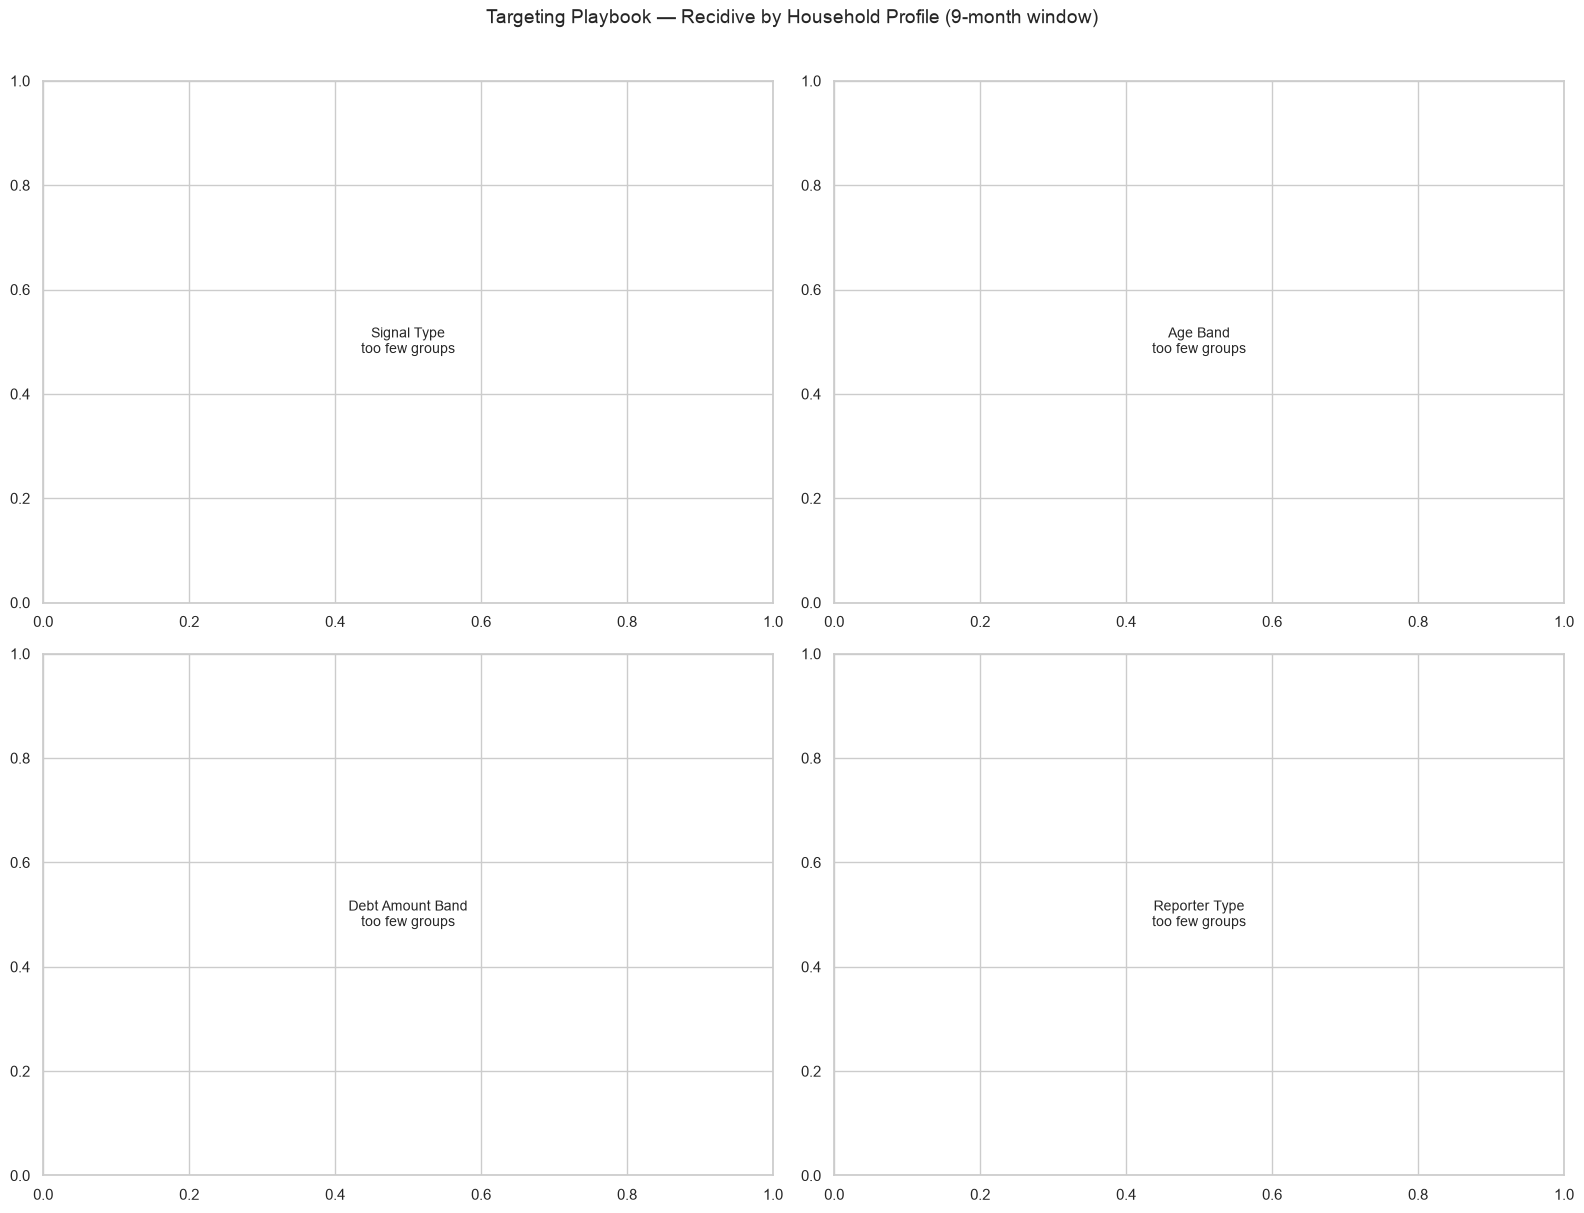


Highest-risk groups (9-month recidive):


In [20]:
_report_section('11. Targeting — Which Groups Have the Highest Recidive Risk?')
MIN_CELL = 30

obs11 = sig[sig['observable_9m']].copy()

def _breakdown(col, label, ax):
    if col not in obs11.columns:
        ax.text(0.5, 0.5, f'{label}\nnot available', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        return
    _g = (obs11.dropna(subset=[col])
          .groupby(col)['recidive_9m']
          .agg(n='count', rate='mean'))
    _g = _g[_g['n'] >= MIN_CELL].sort_values('rate', ascending=True)
    if len(_g) == 0:
        ax.text(0.5, 0.5, f'{label}\ntoo few groups', ha='center', va='center',
                transform=ax.transAxes, fontsize=10)
        return
    _overall = obs11['recidive_9m'].mean() * 100
    _colors_bar = [COLORS[0] if v * 100 > _overall else COLORS[2]
                   for v in _g['rate']]
    _bars = ax.barh(_g.index.astype(str), _g['rate'] * 100, color=_colors_bar)
    for _b in _bars:
        ax.text(_b.get_width() + 0.3, _b.get_y() + _b.get_height()/2,
                f'{_b.get_width():.1f}%', va='center', fontsize=9)
    ax.axvline(_overall, color='red', linestyle='--', linewidth=1.5,
               label=f'Overall {_overall:.1f}%')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'Recidive by {label}')
    ax.set_xlabel('Recidive % (9-month window)')
    ax.legend(fontsize=8)

_dims = [
    ('Type melding', 'Signal Type'),
    ('age_band',     'Age Band'),
    ('debt_band',    'Debt Amount Band'),
    ('Type melder',  'Reporter Type'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for _ax, (_col, _label) in zip(axes.flatten(), _dims):
    _breakdown(_col, _label, _ax)

plt.suptitle('Targeting Playbook — Recidive by Household Profile (9-month window)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Narrative summary ──────────────────────────────────────────────────────────
print("\nHighest-risk groups (9-month recidive):")
for _col, _label in _dims:
    if _col not in obs11.columns:
        continue
    _g = (obs11.dropna(subset=[_col])
          .groupby(_col)['recidive_9m']
          .agg(n='count', rate='mean'))
    _g = _g[_g['n'] >= MIN_CELL].sort_values('rate', ascending=False)
    if len(_g) > 0:
        _top = _g.iloc[0]
        print(f"  {_label:<20}: {_g.index[0]}  →  "
              f"{_top['rate']*100:.1f}% recidive  (n={int(_top['n']):,})")


## 12. Generate the Results File to Send Back

Run this final cell **after running all the cells above**. It writes a single self-contained file —
**`elsa_results_report.html`** — into the same folder as the data, containing every table, chart and
printed summary produced above (charts are embedded directly in the file).

**This is the only file you need to send back.** It opens in any web browser, and to convert it to PDF you
can simply open it and use the browser's *Print → Save as PDF*.

> It contains **aggregated statistics, tables and charts only** — no individual records.


In [21]:
_report_section('12. Generate the Results File to Send Back')
_doc = f'''<!DOCTYPE html>
<html><head><meta charset="utf-8"><title>ELSA Vroegsignalering — Results</title>
<style>
 body{{font-family:-apple-system,Segoe UI,Arial,sans-serif;max-width:1000px;margin:24px auto;
       padding:0 18px;color:#222;line-height:1.4}}
 h1{{border-bottom:3px solid #2c7fb8;padding-bottom:6px}}
 h2.sec{{background:#2c7fb8;color:#fff;padding:6px 12px;border-radius:4px;margin-top:34px}}
 pre{{background:#f6f8fa;padding:8px 10px;border-radius:4px;white-space:pre-wrap;
      font-size:13px;font-family:SFMono-Regular,Consolas,monospace}}
 table{{border-collapse:collapse;margin:10px 0;font-size:13px}}
 th,td{{border:1px solid #ccc;padding:4px 9px;text-align:right}}
 th{{background:#eef3f7}}
 img{{max-width:100%;margin:12px 0;border:1px solid #eee;border-radius:4px}}
 .meta{{color:#666;font-size:13px}}
</style></head><body>
<h1>ELSA Vroegsignalering — Effectiveness Results</h1>
<p class="meta">Generated {_dt.datetime.now():%Y-%m-%d %H:%M} &middot; source file: {_html.escape(str(FILE))}
&middot; {len(_REPORT_BLOCKS)} content blocks</p>
<p class="meta"><em>Aggregated statistics, tables and charts only — no individual records.</em></p>
{''.join(_REPORT_BLOCKS)}
</body></html>'''

# Write next to the notebook's working directory and report the ABSOLUTE path
REPORT_PATH = Path(REPORT_PATH).resolve()
REPORT_PATH.write_text(_doc, encoding='utf-8')

_orig_print("=" * 70)
_orig_print("RESULTS FILE CREATED — this is the file to send back:")
_orig_print(f"   {REPORT_PATH}")
_orig_print("=" * 70)
_orig_print(f"  {len(_REPORT_BLOCKS)} content blocks captured (text, tables, charts).")
_orig_print(f"  Working directory: {Path.cwd()}")
_orig_print("  Open it in any browser; use Print -> Save as PDF if a PDF is preferred.")

# Clickable download link in Jupyter / JupyterLab
try:
    from IPython.display import FileLink
    _ipy_display(FileLink(str(REPORT_PATH)))
except Exception:
    pass

# In Google Colab, trigger a direct browser download automatically
try:
    from google.colab import files as _colab_files   # noqa
    _colab_files.download(str(REPORT_PATH))
except Exception:
    pass


RESULTS FILE CREATED — this is the file to send back:
   /Users/alirezaghavamipour/Downloads/ELSA/elsa_results_report.html
  231 content blocks captured (text, tables, charts).
  Working directory: /Users/alirezaghavamipour/Downloads/ELSA
  Open it in any browser; use Print -> Save as PDF if a PDF is preferred.


/Users/alirezaghavamipour/Downloads/ELSA/elsa_results_report.html